<a href="https://colab.research.google.com/github/nicolasaalves/Checkpoint-3---Engenharia-de-Software/blob/main/Aula_07_(08_04).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📚 Exercício Prático - Hands On

**Contexto:** Modelar o fluxo de "**sacar dinheiro" no app da Nubank** 🟪

## Parte 1 — Diagrama no Miro 🗺️
**Participantes:**
* Usuário
* App Nubank
* Servidor Nubank
* Banco de Dados

**Fluxo a modelar (cenário feliz):**
1. Usuário toca em "Transferir"
2. App solicita valor e destinatário
3. Usuário confirma
4. App envia solicitação ao servidor
5. Servidor verifica saldo no banco de dados
6. Servidor autoriza e debita o saldo
7. App exibe confirmação ao usuário


### **Diagrama:**

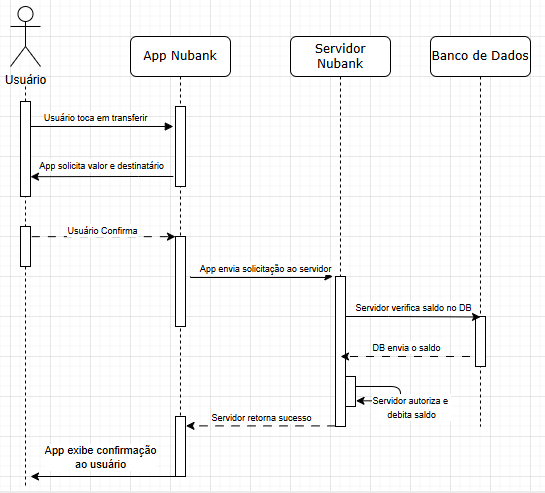

## Parte 2 — Código no Google Colab ou VS Code 🐍
**Código completo**

🧠 Cada classe = um participante | Cada método = uma mensagem do diagrama

### Célula 1 — BancoDeDados (Participante 4)

In [1]:
class BancoDeDados:
    def __init__(self):
        # cria o dicionário com saldo inicial
        self.saldos = {
            "user_123": 500.0
        }

    def verificar_saldo(self, user_id: str) -> float:
        # retorna o saldo do usuário
        return self.saldos.get(user_id, 0.0)

    def debitar(self, user_id: str, valor: float) -> bool:
        saldo = self.verificar_saldo(user_id)

        if saldo >= valor:
            self.saldos[user_id] = saldo - valor
            return True
        else:
            return False

### Célula 2 — ServidorNubank (Participante 3)

In [2]:
class ServidorNubank:
    def __init__(self):
        # instancia o banco de dados
        self.banco = BancoDeDados()

    def processar_transferencia(self, user_id: str, valor: float) -> dict:
        saldo = self.banco.verificar_saldo(user_id)

        # [alt] saldo suficiente
        if saldo >= valor:
            self.banco.debitar(user_id, valor)
            return {
                "status": "aprovado",
                "saldo_restante": self.banco.verificar_saldo(user_id)
            }
        # [else] saldo insuficiente
        else:
            return {
                "status": "recusado",
                "motivo": "saldo insuficiente"
            }

### Célula 3 — AppNubank (Participante 2)

In [3]:
class AppNubank:
    def __init__(self):
        # instancia o servidor
        self.servidor = ServidorNubank()

    def transferir(self, user_id: str, valor: float):
        print(f"[APP] Iniciando transferência de R$ {valor:.2f}...")

        # chama o servidor
        resultado = self.servidor.processar_transferencia(user_id, valor)

        # feedback ao usuário
        if resultado["status"] == "aprovado":
            print(f"✅ Transferência realizada com sucesso!")
            print(f"💰 Saldo restante: R$ {resultado['saldo_restante']:.2f}")
        else:
            print(f"❌ Transferência não realizada!")
            print(f"Motivo: {resultado['motivo']}")

### Célula 4 — Testes

In [4]:
# Rode esta célula só depois de completar as anteriores!
app = AppNubank()
print("=== Teste 1: Transferência dentro do saldo ===")

app.transferir("user_123", 200.0)   # Esperado: ✅ aprovado
print("\n=== Teste 2: Transferência acima do saldo ===")

app.transferir("user_123", 500.0)   # Esperado: ❌ recusado
print("\n=== Teste 3: Múltiplas transferências ===")

app.transferir("user_123", 100.0)   # Esperado: ✅ aprovado (saldo agora 200)
app.transferir("user_123", 250.0)   # Esperado: ❌ recusado (saldo insuficiente)

=== Teste 1: Transferência dentro do saldo ===
[APP] Iniciando transferência de R$ 200.00...
✅ Transferência realizada com sucesso!
💰 Saldo restante: R$ 300.00

=== Teste 2: Transferência acima do saldo ===
[APP] Iniciando transferência de R$ 500.00...
❌ Transferência não realizada!
Motivo: saldo insuficiente

=== Teste 3: Múltiplas transferências ===
[APP] Iniciando transferência de R$ 100.00...
✅ Transferência realizada com sucesso!
💰 Saldo restante: R$ 200.00
[APP] Iniciando transferência de R$ 250.00...
❌ Transferência não realizada!
Motivo: saldo insuficiente
